In [1]:
import pandas as pd
from sklearn.preprocessing import normalize, StandardScaler
import os
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools
import numpy as np

In [40]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

In [3]:
from help_functions import build_kmer_dataset,plot_cumulative_variance, apply_pca_transformation,optimize_and_print_kmeans,optimize_and_print_agglomerative, optimize_and_print_gmm, plot_3d, plot_clustering_comparison_3d, run_hantavirus_clustering_pipeline, analyze_clustering_results, extract_kmer_summary

# Učitavanje podataka

In [4]:
complete_sequences_df = pd.read_csv('../data/processed_sequences/final/complete_sequences.csv')

In [5]:
all_sequences_df = pd.read_csv('../data/processed_sequences/final/all_sequences.csv')

In [6]:
all_6_mers = build_kmer_dataset(all_sequences_df,6,'all_6_mers.csv')

In [7]:
complete_6_mers = build_kmer_dataset(complete_sequences_df,6,'complete_6_mers.csv')

## Kumulativna objašnjena varijansa (PCA za 6-mere)

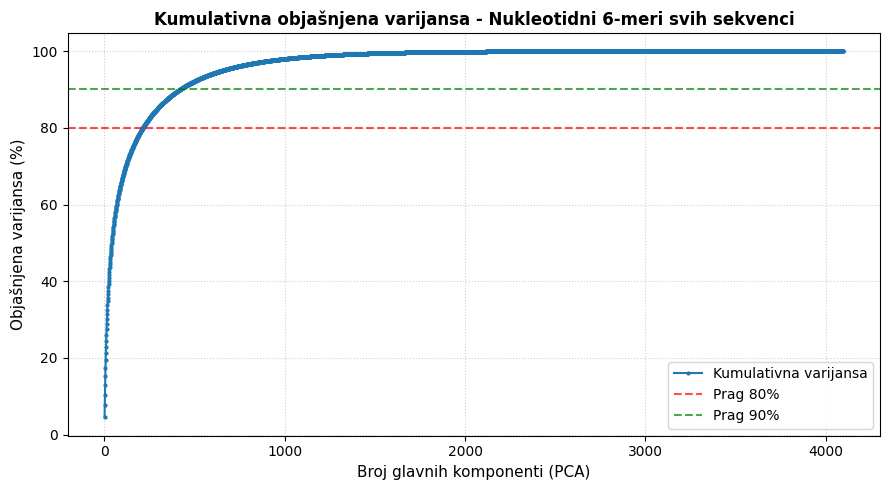

[Nukleotidni 6-meri svih sekvenci] Broj komponenti za 80% varijanse: 214
[Nukleotidni 6-meri svih sekvenci] Broj komponenti za 90% varijanse: 420


In [8]:
plot_cumulative_variance(all_6_mers,'Nukleotidni 6-meri svih sekvenci')

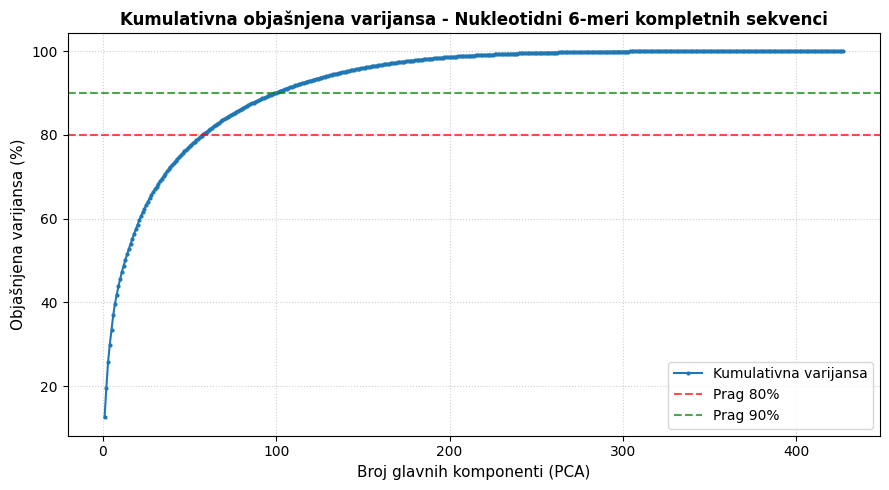

[Nukleotidni 6-meri kompletnih sekvenci] Broj komponenti za 80% varijanse: 58
[Nukleotidni 6-meri kompletnih sekvenci] Broj komponenti za 90% varijanse: 100


In [9]:
plot_cumulative_variance(complete_6_mers,'Nukleotidni 6-meri kompletnih sekvenci')

Analiza 6-mera sa 4096 obeležja ($4^6$),pokazuje još veću raspršenost podataka i potrebu za većim brojem glavnih komponenti:

* **Skup svih sekvenci:**
  * Za prag od 80% objašnjene varijanse potrebno je **214 glavnih komponenti** (420 za 90%).
  * Broj potrebnih komponenti se gotovo udvostručio u odnosu na 5-mere (skok sa 109 na 214). Ovo je posledica ekstremne retkosti matrice, jer kratke sekvence sadrže tek mali broj od mogućih 4096 6-mera.

* **Skup kompletnih sekvenci:**
  * Za očuvanje 80% varijanse potrebno je **58 komponenti** (100 za 90%).

#  Analiza 6-mera kompletnih nukleotida

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 8
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.2798
Davies-Bouldin Index: 1.8140
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 2
Izabrana metrika: euclidean
Tip povezivanja: average
----------------------------------------
Silhouette Score: 0.3056
Davies-Bouldin Index: 0.6409
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 8
Tip kovarijanse: diag
----------------------------------------
Silhouette Score: 0.2802
Davies-Bouldin Index: 1.8201
5. Generisanje uporednog 3D prikaza...


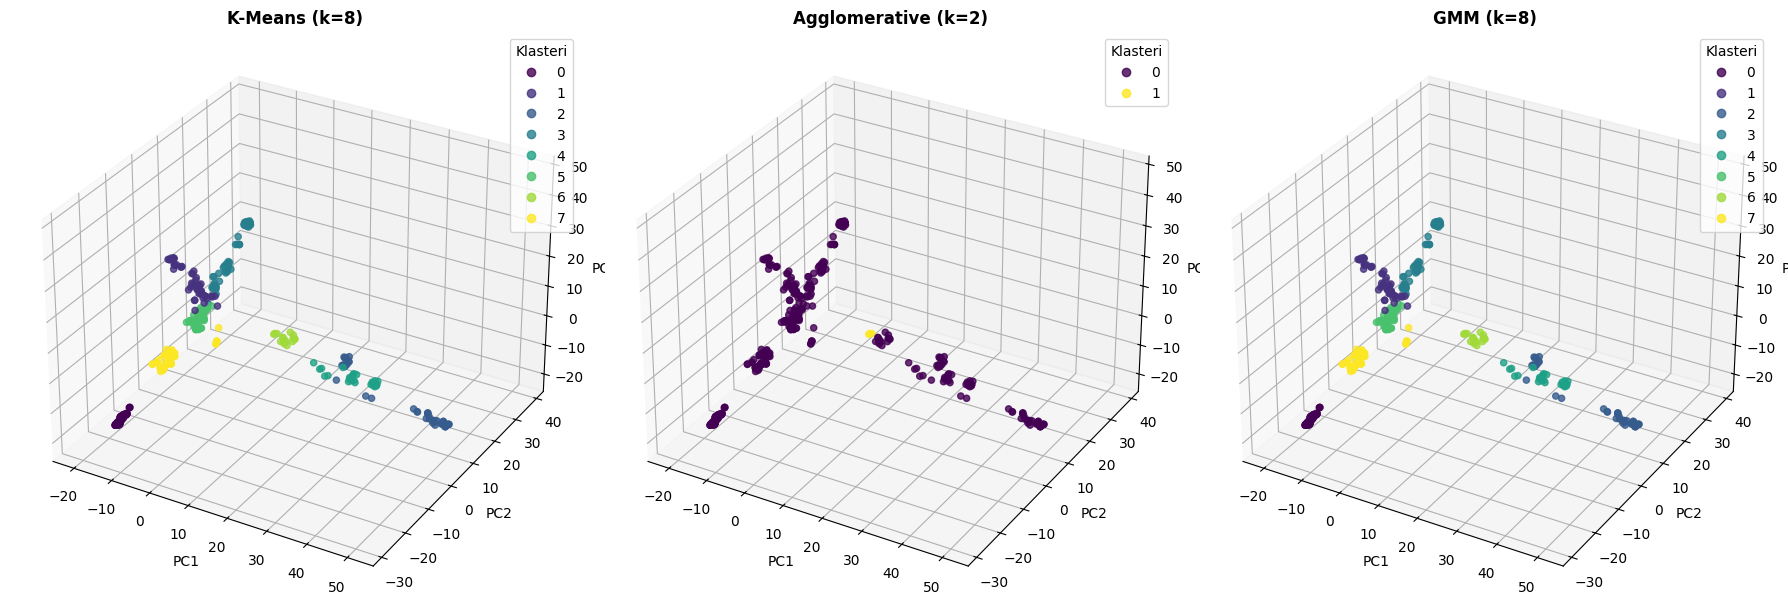

In [10]:
res_complete = run_hantavirus_clustering_pipeline(complete_6_mers, n_components=0.8, plot=True)

### Poređenje rezultata klasterovanja (6-meri kompletnih sekvenci, N = 427)

**Saglasnost algoritama ($k = 8$):** K-Means i GMM ponovo stabilno biraju 8 klastera.

**Pojava efekta lančanja kod aglomerativnog modela:** Prelaskom na 6-mere (4096 dimenzija), aglomerativni model počinje da ispoljava efekte lančanja čak i na skupu kompletnih sekvenci. To je direktna posledica ekstremne retkosti prostora (*sparsity*).

**Poređenje sa 5-merima:** Prelazak na 4096 obeležja pojačava prokletstvo dimenzionalnosti, što uzrokuje očekivan pad silueta koeficijenta i rast DB indeksa, uz degradaciju performansi hijerarhijskog povezivanja.

In [11]:
best_params, best_metrics, agg_labels = optimize_and_print_agglomerative(
    res_complete['X_pca'], 
    cluster_range=range(2, 9),
    linkages=['ward']
)

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 8
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.2919
Davies-Bouldin Index: 1.5292


In [12]:
res_complete['labels']['agglomerative'] = agg_labels
res_complete['params']['agglomerative'] = best_params
res_complete['metrics']['agglomerative'] = best_metrics

In [14]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['kmeans'], 
    data= complete_6_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['agglomerative'], 
    data= complete_6_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['gmm'], 
    data= complete_6_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,69,0,0
1,0,0,53
2,0,0,59
3,0,72,0
4,0,0,32
5,0,57,0
6,0,0,18
7,61,0,6



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,0,69,0,0
1,0,0,53,0
2,0,59,0,0
3,0,72,0,0
4,0,32,0,0
5,12,0,39,6
6,18,0,0,0
7,7,17,31,12



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=69, pretežno L segment) -> Orthohantavirus hantanense: 69 (100.0%)
  Klaster 1 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 2 (N=59, pretežno S segment) -> Orthohantavirus hantanense: 59 (100.0%)
  Klaster 3 (N=72, pretežno M segment) -> Orthohantavirus hantanense: 72 (100.0%)
  Klaster 4 (N=32, pretežno S segment) -> Orthohantavirus hantanense: 32 (100.0%)
  Klaster 5 (N=57, pretežno M segment) -> Orthohantavirus puumalaense: 39 (68.4%), Orthohantavirus dobravaense: 12 (21.1%), Orthohantavirus sinnombreense: 6 (10.5%)
  Klaster 6 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 7 (N=67, pretežno L segment) -> Orthohantavirus puumalaense: 31 (46.3%), Orthohantavirus hantanense: 17 (25.4%), Orthohantavirus sinnombreense: 12 (17.9%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TCACGT (Z=2.08), GTCACG (Z=2.08), AGCGCG (Z=1.95)
  Klaster 1 -> CGCCAT

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=151, pretežno M segment) -> Orthohantavirus puumalaense: 70 (46.4%), Orthohantavirus hantanense: 45 (29.8%), Orthohantavirus dobravaense: 19 (12.6%)
  Klaster 1 (N=35, pretežno S segment) -> Orthohantavirus hantanense: 35 (100.0%)
  Klaster 2 (N=54, pretežno S segment) -> Orthohantavirus puumalaense: 53 (98.1%), Orthohantavirus sinnombreense: 1 (1.9%)
  Klaster 3 (N=44, pretežno M segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 4 (N=44, pretežno S segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 5 (N=69, pretežno L segment) -> Orthohantavirus hantanense: 69 (100.0%)
  Klaster 6 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 7 (N=12, pretežno S segment) -> Orthohantavirus hantanense: 12 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> CTTTGG (Z=0.90), TTTTAA (Z=0.90), CTAGTA (Z=0.89)
  Klaster 1 -> CTTGGA (Z=2.47), CATACG (Z=2.47), GACCGC (Z=2.38)


Segment,L,M,S
Cluster,,,
0,69,0,0
1,0,0,53
2,0,0,59
3,0,71,0
4,0,0,32
5,0,58,0
6,0,0,18
7,61,0,6



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,0,69,0,0
1,0,0,53,0
2,0,59,0,0
3,0,71,0,0
4,0,32,0,0
5,12,1,39,6
6,18,0,0,0
7,7,17,31,12



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=69, pretežno L segment) -> Orthohantavirus hantanense: 69 (100.0%)
  Klaster 1 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 2 (N=59, pretežno S segment) -> Orthohantavirus hantanense: 59 (100.0%)
  Klaster 3 (N=71, pretežno M segment) -> Orthohantavirus hantanense: 71 (100.0%)
  Klaster 4 (N=32, pretežno S segment) -> Orthohantavirus hantanense: 32 (100.0%)
  Klaster 5 (N=58, pretežno M segment) -> Orthohantavirus puumalaense: 39 (67.2%), Orthohantavirus dobravaense: 12 (20.7%), Orthohantavirus sinnombreense: 6 (10.3%)
  Klaster 6 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 7 (N=67, pretežno L segment) -> Orthohantavirus puumalaense: 31 (46.3%), Orthohantavirus hantanense: 17 (25.4%), Orthohantavirus sinnombreense: 12 (17.9%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TCACGT (Z=2.08), GTCACG (Z=2.08), AGCGCG (Z=1.95)
  Klaster 1 -> CGCCAT

### Ključni 6-mer biomarkeri po klasterima (K-Means, N = 427)

Glavna razlika u odnosu na kraće $k$-mere ogleda se u podeli skupa L sekvenci na dva klastera u sva tri algoritma, što predstavlja prvu unutar-segmentnu podelu L segmenata na skupu kompletnih sekvenci.

| Klaster | Dominantni segment i vrsta | Ključni 6-meri | Raspon Z-skora |
|---|---|---|---|
| **Klaster 0** | L segment, *O. hantanense* (100.0%) | `TCACGT`, `GTCACG` | 1.95 - 2.08 | 
| **Klaster 1** | S segment, *O. puumalaense* (100.0%) | `CGCCAT`, `TGACGT` | 2.38 - 2.41 |
| **Klaster 2** | S segment, *O. hantanense* (100.0%) | `GCTGCG`, `CTTGGG` | 2.18 - 2.21 | 
| **Klaster 3** | M segment, *O. hantanense* (100.0%) | `CCCCCA`, `GGTCGT` | 1.78 - 1.89 | 
| **Klaster 4** | S segment, *O. hantanense* (100.0%) | `CATACG`, `TACGTC` | 2.63 - 2.73 | 
| **Klaster 5** | M segment, mešovite vrste  | `GATACC`, `AAAAAA` | 1.72 - 1.77 | 
| **Klaster 6** | S segment, *O. dobravaense* (100.0%) | `AGCCGC`, `GCCGCT` | 3.85 - 4.14 | 
| **Klaster 7** | L segment, mešovite vrste  | `TGATGC`, `ATGTTT` | 1.39 - 1.47 | 

#  Analiza nukleotidnih 6-mera svih sekvenci

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 8
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.1242
Davies-Bouldin Index: 2.2285
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 2
Izabrana metrika: euclidean
Tip povezivanja: complete
----------------------------------------
Silhouette Score: 0.5435
Davies-Bouldin Index: 0.3349
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 2
Tip kovarijanse: spherical
----------------------------------------
Silhouette Score: 0.1540
Davies-Bouldin Index: 1.6349
5. Generisanje uporednog 3D prikaza...


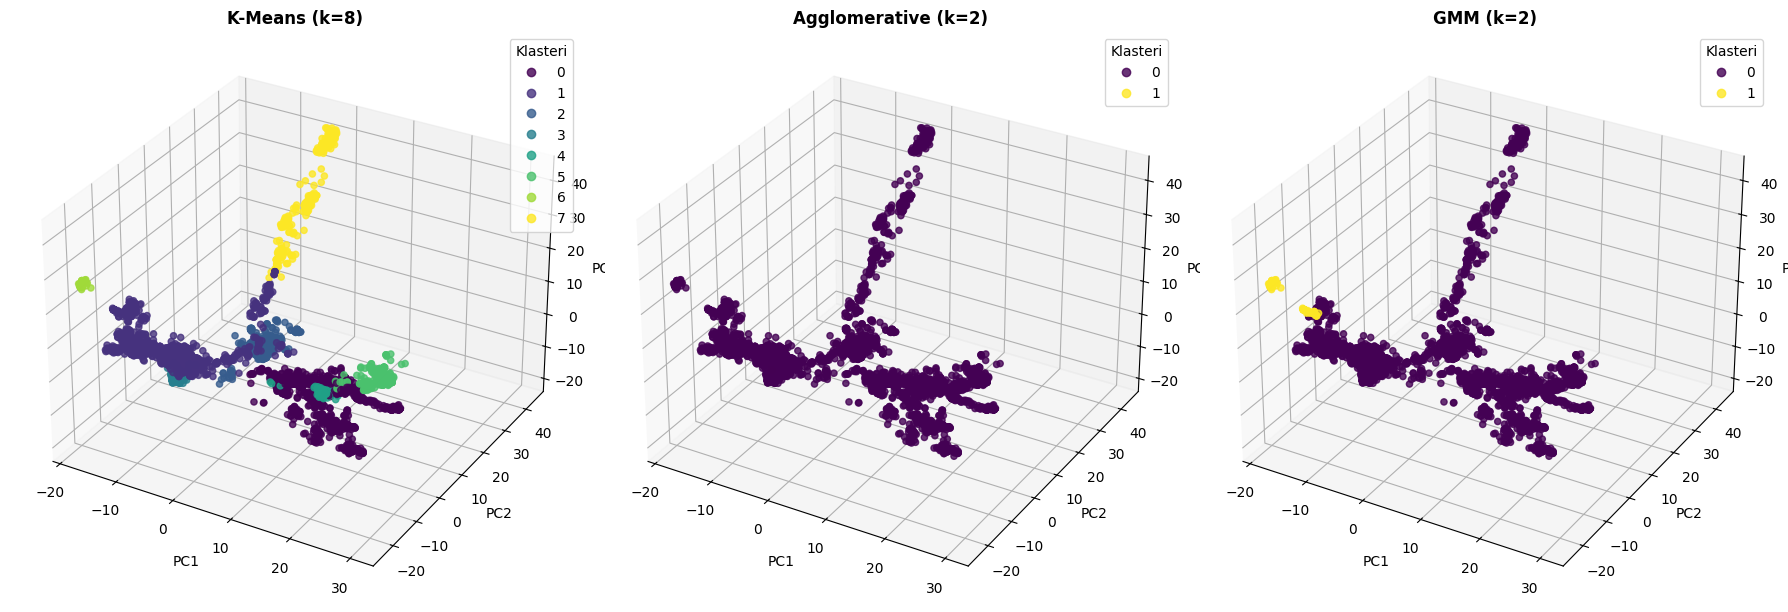

In [15]:
res_all = run_hantavirus_clustering_pipeline(all_6_mers, n_components=0.8, plot=True)

In [17]:
agg_single_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'],
    data=all_6_mers,
    segments=res_all['segments'],
    species=res_all['species'],
    model_name="Agglomerative (Single Linkage)"
)


========================= ANALIZA ZA: AGGLOMERATIVE (SINGLE LINKAGE) =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,880,1483,2815
1,1,0,0



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,438,1667,2827,246
1,0,0,1,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=5178, pretežno S segment) -> Orthohantavirus puumalaense: 2827 (54.6%), Orthohantavirus hantanense: 1667 (32.2%), Orthohantavirus dobravaense: 438 (8.5%)
  Klaster 1 (N=1, pretežno L segment) -> Orthohantavirus puumalaense: 1 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TGATTG (Z=0.00), AAATCA (Z=0.00), AAAAGA (Z=0.00)
  Klaster 1 -> GCGCGA (Z=68.94), TGCGCG (Z=68.23), CGCGAT (Z=49.35)


### Rezultati klasterovanja (6-meri svih sekvenci, N = 5179)
 
* U prostoru od  214 PCA komponenti sa parcijalnim sekvencama, K-Means ostaje jedini model koji zadržava k = 8 kao optimalan broj klastera, pokazujući veću otpornost na prokletstvo dimenzionalnosti.
* Opadanje silueta koeficijenta na 0.1242 i porast Davies-Bouldin indeksa na 2.2285 su posledica kombinacije retkosti matrice heksanukleotida i šuma koji unose nekompletne sekvence.
* Problem ulančavanja aglomerativnog modela se ponovo javlja kao i kod analize prethodnih k-mera na skupu svih sekvenci, pa je ponovo pokrenut sa ograničenjem na Ward povezivanje.
* GMM model gubi mogućnost izdvajanja klastera i razdvaja podatke na dva klastera, pri čemu jedan čini većina instanci.

In [18]:
best_params, best_metrics, agg_labels = optimize_and_print_agglomerative(
    res_all['X_pca'], 
    cluster_range=range(2, 9),
    linkages=['ward']
)

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 8
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.1362
Davies-Bouldin Index: 2.2663


In [19]:
res_all['labels']['agglomerative'] = agg_labels
res_all['params']['agglomerative'] = best_params
res_all['metrics']['agglomerative'] = best_metrics

In [21]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['kmeans'], 
    data= all_6_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'], 
    data= all_6_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['gmm'], 
    data= all_6_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,0,0,1392
1,779,1365,168
2,0,1,642
3,102,0,0
4,0,0,94
5,0,0,272
6,0,117,0
7,0,0,247



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,0,0,1392,0
1,191,1024,851,246
2,0,643,0,0
3,0,0,102,0
4,0,0,94,0
5,0,0,272,0
6,0,0,117,0
7,247,0,0,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=1392, pretežno S segment) -> Orthohantavirus puumalaense: 1392 (100.0%)
  Klaster 1 (N=2312, pretežno M segment) -> Orthohantavirus hantanense: 1024 (44.3%), Orthohantavirus puumalaense: 851 (36.8%), Orthohantavirus sinnombreense: 246 (10.6%)
  Klaster 2 (N=643, pretežno S segment) -> Orthohantavirus hantanense: 643 (100.0%)
  Klaster 3 (N=102, pretežno L segment) -> Orthohantavirus puumalaense: 102 (100.0%)
  Klaster 4 (N=94, pretežno S segment) -> Orthohantavirus puumalaense: 94 (100.0%)
  Klaster 5 (N=272, pretežno S segment) -> Orthohantavirus puumalaense: 272 (100.0%)
  Klaster 6 (N=117, pretežno M segment) -> Orthohantavirus puumalaense: 117 (100.0%)
  Klaster 7 (N=247, pretežno S segment) -> Orthohantavirus dobravaense: 247 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> CACGTG (Z=1.12), ACGTGG (Z=1.11), GACCCG (Z=1.01)
  Klaster 1 -> ATGATG (Z=0.65), TGTTTT (Z=0.61), AAAGTA (Z=0.59)
  Klaster 2 -> 

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=1376, pretežno S segment) -> Orthohantavirus puumalaense: 1287 (93.5%), Orthohantavirus sinnombreense: 89 (6.5%)
  Klaster 1 (N=2117, pretežno M segment) -> Orthohantavirus hantanense: 942 (44.5%), Orthohantavirus puumalaense: 892 (42.1%), Orthohantavirus sinnombreense: 153 (7.2%)
  Klaster 2 (N=335, pretežno S segment) -> Orthohantavirus puumalaense: 335 (100.0%)
  Klaster 3 (N=172, pretežno M segment) -> Orthohantavirus puumalaense: 172 (100.0%)
  Klaster 4 (N=308, pretežno S segment) -> Orthohantavirus dobravaense: 308 (100.0%)
  Klaster 5 (N=79, pretežno M segment) -> Orthohantavirus hantanense: 79 (100.0%)
  Klaster 6 (N=650, pretežno S segment) -> Orthohantavirus hantanense: 646 (99.4%), Orthohantavirus sinnombreense: 4 (0.6%)
  Klaster 7 (N=142, pretežno S segment) -> Orthohantavirus puumalaense: 142 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> GCCAGA (Z=1.06), GACCCG (Z=1.03), GATGAC (Z=1.00)
  

Segment,L,M,S
Cluster,,,
0,881,1320,2815
1,0,163,0



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,438,1667,2665,246
1,0,0,163,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=5016, pretežno S segment) -> Orthohantavirus puumalaense: 2665 (53.1%), Orthohantavirus hantanense: 1667 (33.2%), Orthohantavirus dobravaense: 438 (8.7%)
  Klaster 1 (N=163, pretežno M segment) -> Orthohantavirus puumalaense: 163 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> AAAACA (Z=0.04), TATGGA (Z=0.04), GATGAT (Z=0.03)
  Klaster 1 -> GCTCCC (Z=5.15), GTGATC (Z=4.39), AGTGAG (Z=4.22)


## Interpretacija klastera (6-meri svih sekvenci, N = 5179)

Kao reprezentativni model izabran je K-Means ($k = 8$), pri čemu aglomerativni model (Ward, $k = 8$) pokazuje slične rezultate.

* **Spajanje M i L segmenta (Klaster 1):** Slično kao kod 5-mera, većina M sekvenci (1365) i L sekvenci (779) grupisana je zajedno sa manjim brojem S sekvenci (168) u veliki Klaster 1 ($N = 2312$). Zbog velike heterogenosti segmenata i vrsta i brojnosti samog klastera, Z-skorovi motiva u ovom klasteru su najniži ($Z \approx 0.59 - 0.65$).
* **L segment:**
  * Pored većine u mešovitom klasteru 1, izdvaja se čist L Klaster 3 sa 102 L sekvence specifične isključivo za *O. puumalaense* (100%), uz visok Z-skor motiva `GTAGTG` ($Z = 6.36$).
* **M segment:**
  * Klaster 6: sačinjen isključivo od 117 M sekvenci specifičnih isključivo za *O. puumalaense* (100%), definisanih motivom `GGCGGA` ($Z = 5.73$).
* **S segment:**
  * *O. dobravaense* formira čist Klaster 7 ($N = 247$) sa karakterističnim CpG motivom `GAGCGC` ($Z = 3.77$).
  * *O. hantanense* formira čist Klaster 2 ($N = 643$) uz motiv `CCGTTG` ($Z = 2.09$).
  * *O. puumalaense* se deli na tri čista klastera: veliki Klaster 0 ($N = 1.392$) sa motivom `CACGTG` ($Z = 1.12$), Klaster 5 ($N = 272$) sa motivom `CTTTCG` ($Z = 3.22$) i Klaster 4 ($N = 94$) sa motivom `ACGCAT` ($Z = 6.50$).
* **Malobrojne vrste:**
  * Sve sekvence *O. sinnombreense* (246) ostale su u mešovitom klasteru 1, dok *O. dobravaense* ponovo formira i jedan čist klaster zahvaljujući S segmentu.


### Ključni 6-mer biomarkeri po klasterima (K-Means, N = 5179)

| Klaster | Dominantni segment i vrsta | Ključni 6-meri | Raspon Z-skora |
|---|---|---|---|
| **Klaster 0** | S segment, *O. puumalaense* (100.0%) | `CACGTG`, `ACGTGG` | 1.11 - 1.12 |
| **Klaster 1** | M segment, mešovite vrste | `ATGATG`, `TGTTTT` | 0.61 - 0.65 |
| **Klaster 2** | S segment, *O. hantanense* (100.0%) | `CCGTTG`, `CGTTGT` | 1.91 - 2.09 |
| **Klaster 3** | L segment, *O. puumalaense* (100.0%) | `GTAGTG`, `TTACGT` | 5.41 - 6.36 |
| **Klaster 4** | S segment, *O. puumalaense* (100.0%) | `ACGCAT`, `CGCATA` | 6.26 - 6.50 |
| **Klaster 5** | S segment, *O. puumalaense* (100.0%) | `CTTTCG`, `AACGCC` | 3.16 - 3.22 |
| **Klaster 6** | M segment, *O. puumalaense* (100.0%) | `GGCGGA`, `GCGGAC` | 5.53 - 5.73 |
| **Klaster 7** | S segment, *O. dobravaense* (100.0%) | `GAGCGC`, `AGCGCT` | 3.73 - 3.77 |

# Čuvanje rezultata

In [35]:
row_complete = extract_kmer_summary(res_complete, k_val=6, dataset_type='Complete')

In [36]:
row_all = extract_kmer_summary(res_all, k_val=6, dataset_type='All')

In [37]:
summary_6_mers = pd.DataFrame([row_complete, row_all])

In [38]:
output_path = '../data/sequences_kmers/summary_6_mers.csv'
summary_6_mers.to_csv(output_path, index=False)

In [39]:
summary_6_mers

,k,Dataset,Features,PCA_comps,KMeans_k,KMeans_Sil,KMeans_DB,GMM_k,GMM_Sil,GMM_DB,Agg_k,Agg_linkage,Agg_Sil,Agg_DB
0,6,Complete,4096,58,8,0.2798,1.8140,8,0.2802,1.8201,8,ward,0.2919,1.5292
1,6,All,4096,214,8,0.1242,2.2285,2,0.1540,1.6349,8,ward,0.1362,2.2663
